# 201 — MHC stress-test across ALL alphabets and ksizes (human→mouse orthologs)

**Why MHC, and why every combo.** Notebook 200 ranked every alphabet × k-size combo it has real
genome-wide results for — protein, dayhoff, hp, and all 6 dash-named HP variants (hp-lehninger,
hp-lehninger-plus-c, hp-kyte-doolittle, hp-pbotc-1st-ed, hp-thomas-dill, hp-thomas-dill-no-c), each
across its full validated k range — against MGI ground truth and a matched-scope OrthoFinder
baseline (`ou.load_all_alphabet_ksize_combos()`, the single source of truth shared with 200/203/206).
That's ~99 combos across 9 alphabets. But genome-wide F1 is dominated by high-identity orthologs; it
says nothing about the **hardest** case. MHC is that hardest case: simultaneously kmerseek's weakest
structural class (the antigen-recognition domain is an open β-sheet + α-helix, class-b-heavy) and the
most polymorphic gene family in the genome. This notebook re-runs the same 25-gene human MHC query
against each combo's mouse index and asks three questions per combo:

- **(a)** ortholog recovery / AUC on the HLA↔H-2 set *alone*;
- **(b)** whether the shared k-mers land on the **peptide-binding ARD residues** or ride the conserved scaffold;
- **(c)** how the peptide-binding **ARD** compares to the Ig-like domains **within the same molecules**.

Decision rule: does the genome-wide ranking hold up under this harder test, or does a different combo
(or alphabet) actually pass (a) and (b) cleanly here?

**Every alphabet gets its full k range, not just a top-5.** An earlier version of this notebook
restricted itself to the top-5-per-alphabet from 200's original protein/dayhoff/hp sweep plus a
partial hand-picked extension of 3 HP variants (see git history for that version) — this version
drops the restriction entirely and pulls in every combo 200 has validated, HP-family included: HP
(hp_lehninger and its 5 siblings) is the alphabet family this project cares about most, see
[[feedback_hp_alphabet_priority]]; protein and dayhoff are here as baseline comparisons, at their own
full validated k ranges too, not just their old top-5.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import ortholog_analysis_utils as ou
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve

RES      = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")

# ALL alphabets and ksizes notebook 200 confirmed have real genome-wide results for -- protein,
# dayhoff, hp, and all 6 dash-named HP variants, each across its full validated k range. Single
# source of truth (ou.load_all_alphabet_ksize_combos, reads 200's two sweep CSVs) so this can't
# drift from what 200 actually scored -- add a new alphabet/ksize there first and it shows up here.
combos_df = ou.load_all_alphabet_ksize_combos()
# Drop the legacy "hp" encoding: kmerseek's --help states hp IS the Lehninger classification, and
# they are byte-identical here (hp_k26 and hp_lehninger_k26 both give exactly 3,266 MHC rows). It
# survives in 200's sweep only because those combos predate the explicitly-named HP variants, and
# its files are the older human_vs_mouse.hp.k*.results.csv.gz set -- partly absent (k23, k25) and
# partly corrupt (k21 fails `gzip -t`). hp-lehninger covers the same k range from current parquets.
combos_df = combos_df.filter(pl.col("dash_encoding") != "hp")
COMBOS = list(zip(combos_df["dash_encoding"].to_list(), combos_df["ksize"].to_list()))
ALPHABET_DISPLAY_NAMES = dict(zip(combos_df["dash_encoding"].to_list(), combos_df["display_encoding"].to_list()))
print(f"{len(COMBOS)} combos across {combos_df['display_encoding'].n_unique()} alphabets:")
print(combos_df.group_by("display_encoding")
      .agg(pl.col("ksize").min().alias("k_min"), pl.col("ksize").max().alias("k_max"), pl.len().alias("n_k"))
      .sort("display_encoding"))

# kmerseek's `--encoding hp` is specifically the Lehninger classification (per its own --help:
# "hp: HP encoding -- sourmash built-in Lehninger classification") -- byte-identical to
# `--encoding hp-lehninger` (verified in notebook 200), but 200 tracks them as separate combos, so
# both appear here too. Labeled by ALPHABET_DISPLAY_NAMES everywhere below to avoid ambiguity.
def combo_label(enc: str, k: int) -> str:
    return f"{ALPHABET_DISPLAY_NAMES.get(enc, enc)}_k{k}"

# Structural taxonomy of the human MHC/HLA query set (gene symbol -> class)
MHC_CLASSES = {
    "HLA-A": "I classical", "HLA-B": "I classical", "HLA-C": "I classical",
    "HLA-E": "I non-classical", "HLA-F": "I non-classical", "HLA-G": "I non-classical",
    "MICA": "I related (MIC)", "MICB": "I related (MIC)",
    "HLA-DRA": "II alpha", "HLA-DQA1": "II alpha", "HLA-DQA2": "II alpha",
    "HLA-DPA1": "II alpha", "HLA-DMA": "II alpha", "HLA-DOA": "II alpha",
    "HLA-DRB1": "II beta", "HLA-DRB5": "II beta", "HLA-DQB1": "II beta", "HLA-DQB2": "II beta",
    "HLA-DPB1": "II beta", "HLA-DMB": "II beta", "HLA-DOB": "II beta",
    "B2M": "light chain", "TAP1": "processing (ctrl)", "TAP2": "processing (ctrl)",
    "TAPBP": "processing (ctrl)",
}
CLASS_ORDER = ["I classical", "I non-classical", "I related (MIC)", "II alpha", "II beta",
               "light chain", "processing (ctrl)"]
COLORS = {"I classical": "#D65F5F", "I non-classical": "#E1917F", "I related (MIC)": "#C4AD66",
          "II alpha": "#4878CF", "II beta": "#77BEDB", "light chain": "#6ACC65",
          "processing (ctrl)": "#999999"}

# Per-alphabet color families (hue = alphabet, shade = k-size rank within alphabet) -- shared
# with 203/206 (ou.alphabet_combo_colors) so they can't each hand-roll a different color scheme
# for the same "all alphabets and ksizes" sweep.
ALPHABET_CMAPS, COMBO_COLORS = ou.alphabet_combo_colors(COMBOS, ALPHABET_DISPLAY_NAMES)


90 combos across 8 alphabets:
shape: (8, 4)
┌─────────────────────┬───────┬───────┬─────┐
│ display_encoding    ┆ k_min ┆ k_max ┆ n_k │
│ ---                 ┆ ---   ┆ ---   ┆ --- │
│ str                 ┆ i64   ┆ i64   ┆ u32 │
╞═════════════════════╪═══════╪═══════╪═════╡
│ dayhoff             ┆ 12    ┆ 20    ┆ 9   │
│ hp_kyte_doolittle   ┆ 18    ┆ 30    ┆ 10  │
│ hp_lehninger        ┆ 18    ┆ 30    ┆ 13  │
│ hp_lehninger_plus_c ┆ 18    ┆ 30    ┆ 13  │
│ hp_pbotc_1st_ed     ┆ 18    ┆ 30    ┆ 13  │
│ hp_thomas_dill      ┆ 19    ┆ 30    ┆ 12  │
│ hp_thomas_dill_no_c ┆ 21    ┆ 30    ┆ 10  │
│ protein             ┆ 6     ┆ 15    ┆ 10  │
└─────────────────────┴───────┴───────┴─────┘


## 0. Build the query & run the search for each combo

The query FASTA (25 human MHC molecules, one canonical isoform each) is searched against the **full**
mouse proteome index for each combo — so each human gene competes against all ~21k mouse proteins, not
a curated shortlist. Cached per combo: only reruns a combo if its results CSV is missing.

In [2]:
# Load each combo's MHC matched regions from the GENOME-WIDE pipeline results.
#
# This notebook deliberately does NOT run `kmerseek search` itself -- searching belongs in the
# Nextflow pipeline, not in analysis notebooks. Verified equivalent before switching: filtering
# the genome-wide parquet to the 25 MHC genes reproduces the old per-combo search CSVs exactly
# (hp_lehninger k26 3,266 rows, protein k13 226, dayhoff k18 547 -- identical row counts, genes,
# and containment ranges). The pipeline stores results unfiltered, so nothing is lost by reading
# them instead of re-searching, and 200/201 can no longer disagree about the same combo.
#
# A combo with no genome-wide result is reported and SKIPPED, never searched around: that is a
# gap for the pipeline to fill (hp-thomas-dill k18 is currently one, an empty-index stub).
frames, missing, unreadable, no_hits = [], [], [], []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    cache_csv = RES / f"201_human_mhc_vs_mouse.{label}.csv"

    if cache_csv.exists():
        combo_df = pl.read_csv(cache_csv)
    else:
        try:
            combo_df = (
                ou.scan_genome_wide_results(enc, k)
                .with_columns(
                    pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("_hg"))
                .filter(pl.col("_hg").is_in(list(MHC_CLASSES)))
                .drop("_hg")
                .collect(engine="streaming")
            )
        except FileNotFoundError:
            missing.append(label)
            print(f"{label:18s}: NO genome-wide result -- run it in the pipeline, skipping")
            continue
        except Exception as exc:
            # An unreadable source (e.g. the truncated legacy human_vs_mouse.hp.k21.results.csv.gz,
            # which fails `gzip -t`) is a pipeline-side data problem, not something to work around
            # here. Report it and keep going so one bad file can't abort the whole sweep.
            unreadable.append(label)
            print(f"{label:18s}: UNREADABLE source ({type(exc).__name__}) -- "
                  f"re-run it in the pipeline, skipping")
            continue
        if combo_df.height:
            combo_df.write_csv(cache_csv)  # cache so later runs don't rescan the parquet

    combo_df = combo_df.with_columns([
        pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
        pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
        pl.lit(label).alias("combo"),
        pl.lit(enc).alias("encoding"),
        pl.lit(k).alias("ksize"),
    ])
    if combo_df.height == 0:
        # Two reasons this matters. (1) A 0-row frame read back from a header-only cache CSV has
        # every column typed String, and pl.concat(how="diagonal_relaxed") then widens Float64 ->
        # String across ALL combos, so containment/poisson_pvalue arrive at roc_auc_score as text.
        # (2) A zero here has never yet meant "no homology": every observed case was an INCOMPLETE
        # pipeline run (hp-kyte-doolittle k22 has 55M rows but covers only 997 of ~19,664 human
        # genes, so MHC was simply never searched). Excluded and reported, never plotted as signal.
        no_hits.append(label)
        print(f"{label:18s}: 0 rows -- 0/25 MHC genes; check the pipeline run for this combo")
        continue
    frames.append(combo_df)
    print(f"{label:18s}: {len(combo_df):,} matched-region rows | "
          f"{combo_df['human_gene'].n_unique()}/25 human genes returned >=1 hit")

df = pl.concat(frames, how="diagonal_relaxed")
print(f"\nTotal rows across {len(frames)}/{len(COMBOS)} combos: {len(df):,}")
if missing:
    print(f"Missing from the pipeline ({len(missing)}): {', '.join(missing)}")
if unreadable:
    print(f"Unreadable/corrupt sources ({len(unreadable)}): {', '.join(unreadable)}")
if no_hits:
    print(f"Zero-row combos, likely incomplete pipeline runs ({len(no_hits)}): {', '.join(no_hits)}")
assert df.select(pl.col("containment").cast(pl.Float64, strict=True)).height == df.height
df.select(["combo", "human_gene", "mouse_gene", "containment", "n_intersecting_hashes",
           "query_start", "query_end", "region_length"]).head(4)


dayhoff_k12       : 5,826 matched-region rows | 25/25 human genes returned >=1 hit
dayhoff_k13       : 2,194 matched-region rows | 25/25 human genes returned >=1 hit
dayhoff_k14       : 1,235 matched-region rows | 24/25 human genes returned >=1 hit
dayhoff_k15       : 881 matched-region rows | 24/25 human genes returned >=1 hit
dayhoff_k16       : 727 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k17       : 599 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k18       : 547 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k19       : 480 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k20       : 363 matched-region rows | 22/25 human genes returned >=1 hit


hp_kyte_doolittle_k18: 0 rows -- 0/25 MHC genes; check the pipeline run for this combo
hp_kyte_doolittle_k22: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k23: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k24: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k25: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k26: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k27: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k28: 2,197 matched-region rows | 25/25 human genes returned >=1 hit
hp_kyte_doolittle_k29: 1,327 matched-region rows | 25/25 human genes returned >=1 hit
hp_kyte_doolittle_k30: 700 matched-region rows | 25/25 human genes returned >=1 hit


hp_lehninger_k18  : 426,193 matched-region rows | 25/25 human genes returned >=1 hit


hp_lehninger_k19  : 235,448 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k20  : 131,337 matched-region rows | 25/25 human genes returned >=1 hit


hp_lehninger_k21  : 72,762 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k22  : 40,414 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k23  : 21,984 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k24  : 11,435 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k25  : 6,334 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k26  : 3,266 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k27  : 1,498 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k28  : 772 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k29  : 471 matched-region rows | 24/25 human genes returned >=1 hit
hp_lehninger_k30  : 278 matched-region rows | 24/25 human genes returned >=1 hit


...

hp_lehninger_plus_c_k20: 220,319 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k21: 128,075 matched-region rows | 25/25 human genes returned >=1 hit


hp_lehninger_plus_c_k22: 74,287 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k23: 41,376 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k24: 21,754 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k25: 12,104 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k26: 6,834 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k27: 3,521 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k28: 1,412 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k29: 723 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k30: 396 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k18: NO genome-wide result -- run it in the pipeline, skipping


hp_pbotc_1st_ed_k19: 99,025 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k20: 49,707 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k21: 25,004 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k22: 12,541 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k23: 6,340 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k24: 3,195 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k25: 1,705 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k26: 976 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k27: 543 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k28: 359 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k29: 220 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k30: 154 matched-region rows | 24/25 human genes returned >=1 hi

hp_thomas_dill_k26: 1,774 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_k27: 1,007 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_k28: 607 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_k29: 415 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_k30: 256 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_no_c_k21: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_no_c_k22: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_no_c_k23: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_no_c_k24: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_no_c_k25: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_no_c_k26: 2,899 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_no_c_k27: 1,725 matched-region rows | 25/25 human genes returned >=1 hit


combo,human_gene,mouse_gene,containment,n_intersecting_hashes,query_start,query_end,region_length
str,str,str,f64,i64,i64,i64,i64
"""dayhoff_k12""","""HLA-F""","""MFSD14A""",0.00232,1,4,16,12
"""dayhoff_k12""","""HLA-F""","""GPR151""",0.00232,1,317,329,12
"""dayhoff_k12""","""HLA-F""","""H2-T22""",0.053364,23,201,214,13
"""dayhoff_k12""","""HLA-F""","""H2-T22""",0.053364,23,220,239,19


In [3]:
# MGI ground truth, restricted to the MHC query genes
mgi = pl.read_csv(RES / "HOM_MouseHumanSequence.rpt", separator="\t", infer_schema_length=10_000)
h = mgi.filter(pl.col("NCBI Taxon ID") == 9606).select(["DB Class Key", "Symbol"]).rename({"Symbol": "human_gene"})
m = mgi.filter(pl.col("NCBI Taxon ID") == 10090).select(["DB Class Key", "Symbol"]).rename({"Symbol": "mouse_gene"})
mgi_pairs = (h.join(m, on="DB Class Key")
             .with_columns([pl.col("human_gene").str.to_uppercase(), pl.col("mouse_gene").str.to_uppercase()])
             .select(["human_gene", "mouse_gene"]).unique())
TRUTH = set(zip(mgi_pairs["human_gene"].to_list(), mgi_pairs["mouse_gene"].to_list()))

# Best score per (combo, human, mouse) pair, tagged with MGI truth
pair = (df.group_by(["combo", "encoding", "ksize", "human_gene", "mouse_gene"])
        .agg(pl.col("containment").max(), pl.col("poisson_pvalue").min(),
             pl.col("n_intersecting_hashes").max())
        .with_columns([
            pl.col("human_gene").replace_strict(MHC_CLASSES, default="other").alias("mhc_class"),
            pl.struct(["human_gene", "mouse_gene"])
              .map_elements(lambda s: (s["human_gene"], s["mouse_gene"]) in TRUTH, return_dtype=pl.Boolean)
              .alias("is_ortholog"),
        ]))
print(f"MHC hit-pairs across all combos: {len(pair):,}")
for label in [combo_label(e, k) for e, k in COMBOS]:
    sub = pair.filter(pl.col("combo") == label)
    print(f"  {label:14s}: {len(sub):,} pairs | MGI-true among them: {int(sub['is_ortholog'].sum())}")

MHC hit-pairs across all combos: 1,124,911
  dayhoff_k12   : 4,407 pairs | MGI-true among them: 86
  dayhoff_k13   : 1,330 pairs | MGI-true among them: 86
  dayhoff_k14   : 535 pairs | MGI-true among them: 86
  dayhoff_k15   : 345 pairs | MGI-true among them: 86
  dayhoff_k16   : 254 pairs | MGI-true among them: 85
  dayhoff_k17   : 207 pairs | MGI-true among them: 84
  dayhoff_k18   : 196 pairs | MGI-true among them: 84
  dayhoff_k19   : 187 pairs | MGI-true among them: 82
  dayhoff_k20   : 168 pairs | MGI-true among them: 73
  hp_kyte_doolittle_k18: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k22: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k23: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k24: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k25: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k26: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k27: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k28: 2,001 pairs | MGI-true among them: 5

  hp_pbotc_1st_ed_k27: 480 pairs | MGI-true among them: 38
  hp_pbotc_1st_ed_k28: 309 pairs | MGI-true among them: 35
  hp_pbotc_1st_ed_k29: 182 pairs | MGI-true among them: 27
  hp_pbotc_1st_ed_k30: 123 pairs | MGI-true among them: 26
  hp_thomas_dill_k19: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_k20: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_k21: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_k22: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_k23: 10,193 pairs | MGI-true among them: 82
  hp_thomas_dill_k24: 5,448 pairs | MGI-true among them: 82
  hp_thomas_dill_k25: 2,929 pairs | MGI-true among them: 62
  hp_thomas_dill_k26: 1,611 pairs | MGI-true among them: 53
  hp_thomas_dill_k27: 901 pairs | MGI-true among them: 50
  hp_thomas_dill_k28: 529 pairs | MGI-true among them: 46
  hp_thomas_dill_k29: 354 pairs | MGI-true among them: 46
  hp_thomas_dill_k30: 207 pairs | MGI-true among them: 33
  hp_thomas_dill_no_c_k21: 0 pairs | MGI-true among them: 0
  hp_thomas

## 1. (a) Ortholog recovery & AUC on MHC alone, per combo

For each combo and each human MHC gene, rank all its mouse hits by containment and ask where its true
MGI ortholog(s) land. `recovery@1` / `@5` = true ortholog is the top / top-5 hit; `median rank` =
typical position of the best true ortholog (999 = never returned).

In [4]:
def recovery_table(pair_df, truth):
    rows = []
    for cls in CLASS_ORDER:
        genes = [g for g, c in MHC_CLASSES.items() if c == cls]
        n_with = r1 = r5 = 0
        ranks = []
        for g in genes:
            gt = {mm for (hh, mm) in truth if hh == g}
            if not gt:
                continue
            n_with += 1
            sub = pair_df.filter(pl.col("human_gene") == g).sort("containment", descending=True)
            mgs = sub["mouse_gene"].to_list()
            hits = [i + 1 for i, x in enumerate(mgs) if x in gt]
            if hits:
                best = min(hits); ranks.append(best)
                r1 += best == 1; r5 += best <= 5
            else:
                ranks.append(999)
        rows.append({"class": cls, "n_genes_with_MGI": n_with,
                     "recovery@1": r1, "recovery@5": r5,
                     "median_rank": int(np.median(ranks)) if ranks else -1})
    return pl.DataFrame(rows)

def auc_block(sub):
    y = sub["is_ortholog"].to_numpy().astype(int)
    s = sub["containment"].to_numpy()
    if y.sum() == 0 or y.sum() == len(y):
        return (np.nan, np.nan, int(y.sum()), len(y))
    return (roc_auc_score(y, s), average_precision_score(y, s), int(y.sum()), len(y))

# Per-combo recovery tables + AUC blocks
recovery_by_combo: dict[str, pl.DataFrame] = {}
auc_by_combo: dict[str, dict] = {}
groups_by_combo: dict[str, dict] = {}

print(f"{'combo':14s} {'scope':22s} {'AUC-ROC':>8s} {'AvgPrec':>8s} {'pos':>4s} {'n_hits':>7s}")
for enc, k in COMBOS:
    label = combo_label(enc, k)
    combo_pair = pair.filter(pl.col("combo") == label)
    recovery_by_combo[label] = recovery_table(combo_pair, TRUTH)
    groups = {
        "ALL MHC": combo_pair,
        "class I (A/B/C/E/F/G)": combo_pair.filter(pl.col("mhc_class").str.starts_with("I ") & ~pl.col("mhc_class").str.contains("MIC")),
        "class II (α+β)": combo_pair.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    groups_by_combo[label] = groups
    auc_by_combo[label] = {}
    for name, sub in groups.items():
        a, ap, pos, n = auc_block(sub)
        auc_by_combo[label][name] = dict(auc_roc=a, auc_pr=ap, pos=pos, n=n)
        print(f"{label:14s} {name:22s} {a:8.3f} {ap:8.3f} {pos:4d} {n:7d}")
    print()

recovery_by_combo[combo_label(*COMBOS[0])]

combo          scope                   AUC-ROC  AvgPrec  pos  n_hits
dayhoff_k12    ALL MHC                   0.994    0.761   86    4407
dayhoff_k12    class I (A/B/C/E/F/G)     0.974    0.678   69    1018
dayhoff_k12    class II (α+β)            0.999    0.953   13    1070

dayhoff_k13    ALL MHC                   0.978    0.729   86    1330
dayhoff_k13    class I (A/B/C/E/F/G)     0.919    0.626   69     402
dayhoff_k13    class II (α+β)            0.996    0.944   13     285



dayhoff_k14    ALL MHC                   0.932    0.696   86     535
dayhoff_k14    class I (A/B/C/E/F/G)     0.807    0.581   69     221
dayhoff_k14    class II (α+β)            0.986    0.933   13     100

dayhoff_k15    ALL MHC                   0.868    0.662   86     345
dayhoff_k15    class I (A/B/C/E/F/G)     0.743    0.541   69     193
dayhoff_k15    class II (α+β)            0.975    0.941   13      61



dayhoff_k16    ALL MHC                   0.789    0.637   85     254
dayhoff_k16    class I (A/B/C/E/F/G)     0.632    0.511   69     162
dayhoff_k16    class II (α+β)            0.951    0.938   13      39

dayhoff_k17    ALL MHC                   0.698    0.611   84     207
dayhoff_k17    class I (A/B/C/E/F/G)     0.593    0.496   68     154
dayhoff_k17    class II (α+β)            0.933    0.936   13      33

dayhoff_k18    ALL MHC                   0.644    0.586   84     196
dayhoff_k18    class I (A/B/C/E/F/G)     0.575    0.483   68     154
dayhoff_k18    class II (α+β)            0.888    0.936   13      25



dayhoff_k19    ALL MHC                   0.593    0.551   82     187
dayhoff_k19    class I (A/B/C/E/F/G)     0.528    0.455   66     148
dayhoff_k19    class II (α+β)            0.850    0.932   13      23

dayhoff_k20    ALL MHC                   0.553    0.519   73     168
dayhoff_k20    class I (A/B/C/E/F/G)     0.474    0.416   59     134
dayhoff_k20    class II (α+β)            1.000    1.000   11      20



hp_kyte_doolittle_k18 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k18 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k18 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k22 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k22 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k22 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k23 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k23 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k23 class II (α+β)              nan      nan    0       0



...

hp_thomas_dill_no_c_k24 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k24 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k24 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k25 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k25 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k25 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k26 ALL MHC                   0.872    0.418   57    2326
hp_thomas_dill_no_c_k26 class I (A/B/C/E/F/G)     0.823    0.186   40    1077
hp_thomas_dill_no_c_k26 class II (α+β)            0.998    0.942   13     566

hp_thomas_dill_no_c_k27 ALL MHC                   0.862    0.450   53    1280
hp_thomas_dill_no_c_k27 class I (A/B/C/E/F/G)     0.784    0.198   36     591
hp_thomas_dill_no_c_k27 class II (α+β)            0.997    0.943   13     304

hp_thomas_dill_no_c_k28 ALL MHC                   0.836    0

hp_thomas_dill_no_c_k29 ALL MHC                   0.729    0.484   49     468
hp_thomas_dill_no_c_k29 class I (A/B/C/E/F/G)     0.582    0.224   32     244
hp_thomas_dill_no_c_k29 class II (α+β)            0.987    0.916   13      94

hp_thomas_dill_no_c_k30 ALL MHC                   0.852    0.608   37     282
hp_thomas_dill_no_c_k30 class I (A/B/C/E/F/G)     0.752    0.279   20     153
hp_thomas_dill_no_c_k30 class II (α+β)            0.975    0.916   13      60

protein_k6     ALL MHC                   0.996    0.795   86    6569
protein_k6     class I (A/B/C/E/F/G)     0.987    0.711   69    2065
protein_k6     class II (α+β)            1.000    1.000   13    2014

protein_k7     ALL MHC                   0.951    0.744   86     685
protein_k7     class I (A/B/C/E/F/G)     0.867    0.637   69     313
protein_k7     class II (α+β)            1.000    0.995   13     172

protein_k8     ALL MHC                   0.812    0.697   86     271
protein_k8     class I (A/B/C/E/F/G)     0.67

protein_k9     ALL MHC                   0.683    0.652   86     213
protein_k9     class I (A/B/C/E/F/G)     0.544    0.518   69     165
protein_k9     class II (α+β)            0.981    0.982   13      29

protein_k10    ALL MHC                   0.603    0.616   85     195
protein_k10    class I (A/B/C/E/F/G)     0.488    0.468   69     162
protein_k10    class II (α+β)            0.958    0.967   13      25

protein_k11    ALL MHC                   0.540    0.562   85     189
protein_k11    class I (A/B/C/E/F/G)     0.434    0.410   69     159
protein_k11    class II (α+β)            0.906    0.950   13      22

protein_k12    ALL MHC                   0.493    0.522   84     186
protein_k12    class I (A/B/C/E/F/G)     0.408    0.386   68     158
protein_k12    class II (α+β)            0.824    0.926   13      20

protein_k13    ALL MHC                   0.499    0.510   72     166
protein_k13    class I (A/B/C/E/F/G)     0.427    0.362   57     143
protein_k13    class II (α+β) 

protein_k14    ALL MHC                   0.351    0.474   68     141
protein_k14    class I (A/B/C/E/F/G)     0.269    0.337   54     121
protein_k14    class II (α+β)            0.773    0.931   11      15

protein_k15    ALL MHC                   0.330    0.463   65     136
protein_k15    class I (A/B/C/E/F/G)     0.226    0.324   53     118
protein_k15    class II (α+β)            0.875    0.953    9      13



class,n_genes_with_MGI,recovery@1,recovery@5,median_rank
str,i64,i64,i64,i64
"""I classical""",3,2,3,1
"""I non-classical""",3,2,3,1
"""I related (MIC)""",2,0,0,999
"""II alpha""",5,4,4,1
"""II beta""",6,4,6,1
"""light chain""",1,1,1,1
"""processing (ctrl)""",3,3,3,1


In [5]:
# Class I -> H-2 signal by alphabet: does HP (weakest genome-wide) actually do better here,
# echoing the earlier thomas_dill-vs-plain-hp observation, now that HP is a real tested combo?
ci_genes = [g for g, c in MHC_CLASSES.items() if c.startswith("I ") and "MIC" not in c]
print("class I heavy chains reaching ANY H-2 hit, by combo:")
for enc, k in COMBOS:
    label = combo_label(enc, k)
    td_ci = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(ci_genes)
                       & pl.col("mouse_gene").str.starts_with("H2-"))
    print(f"  {label:14s}: {td_ci.height:4d} matched regions to H-2 genes, {td_ci['human_gene'].n_unique()}/6 genes")

class I heavy chains reaching ANY H-2 hit, by combo:
  dayhoff_k12   :  757 matched regions to H-2 genes, 6/6 genes


  dayhoff_k13   :  658 matched regions to H-2 genes, 6/6 genes
  dayhoff_k14   :  574 matched regions to H-2 genes, 6/6 genes


  dayhoff_k15   :  460 matched regions to H-2 genes, 6/6 genes
  dayhoff_k16   :  419 matched regions to H-2 genes, 6/6 genes


  dayhoff_k17   :  361 matched regions to H-2 genes, 6/6 genes
  dayhoff_k18   :  334 matched regions to H-2 genes, 6/6 genes


  dayhoff_k19   :  286 matched regions to H-2 genes, 6/6 genes
  dayhoff_k20   :  185 matched regions to H-2 genes, 6/6 genes


...

  protein_k7    :  775 matched regions to H-2 genes, 6/6 genes
  protein_k8    :  592 matched regions to H-2 genes, 6/6 genes


  protein_k9    :  480 matched regions to H-2 genes, 6/6 genes
  protein_k10   :  403 matched regions to H-2 genes, 6/6 genes


  protein_k11   :  345 matched regions to H-2 genes, 6/6 genes
  protein_k12   :  311 matched regions to H-2 genes, 6/6 genes


  protein_k13   :  172 matched regions to H-2 genes, 6/6 genes
  protein_k14   :  146 matched regions to H-2 genes, 6/6 genes


  protein_k15   :  132 matched regions to H-2 genes, 6/6 genes


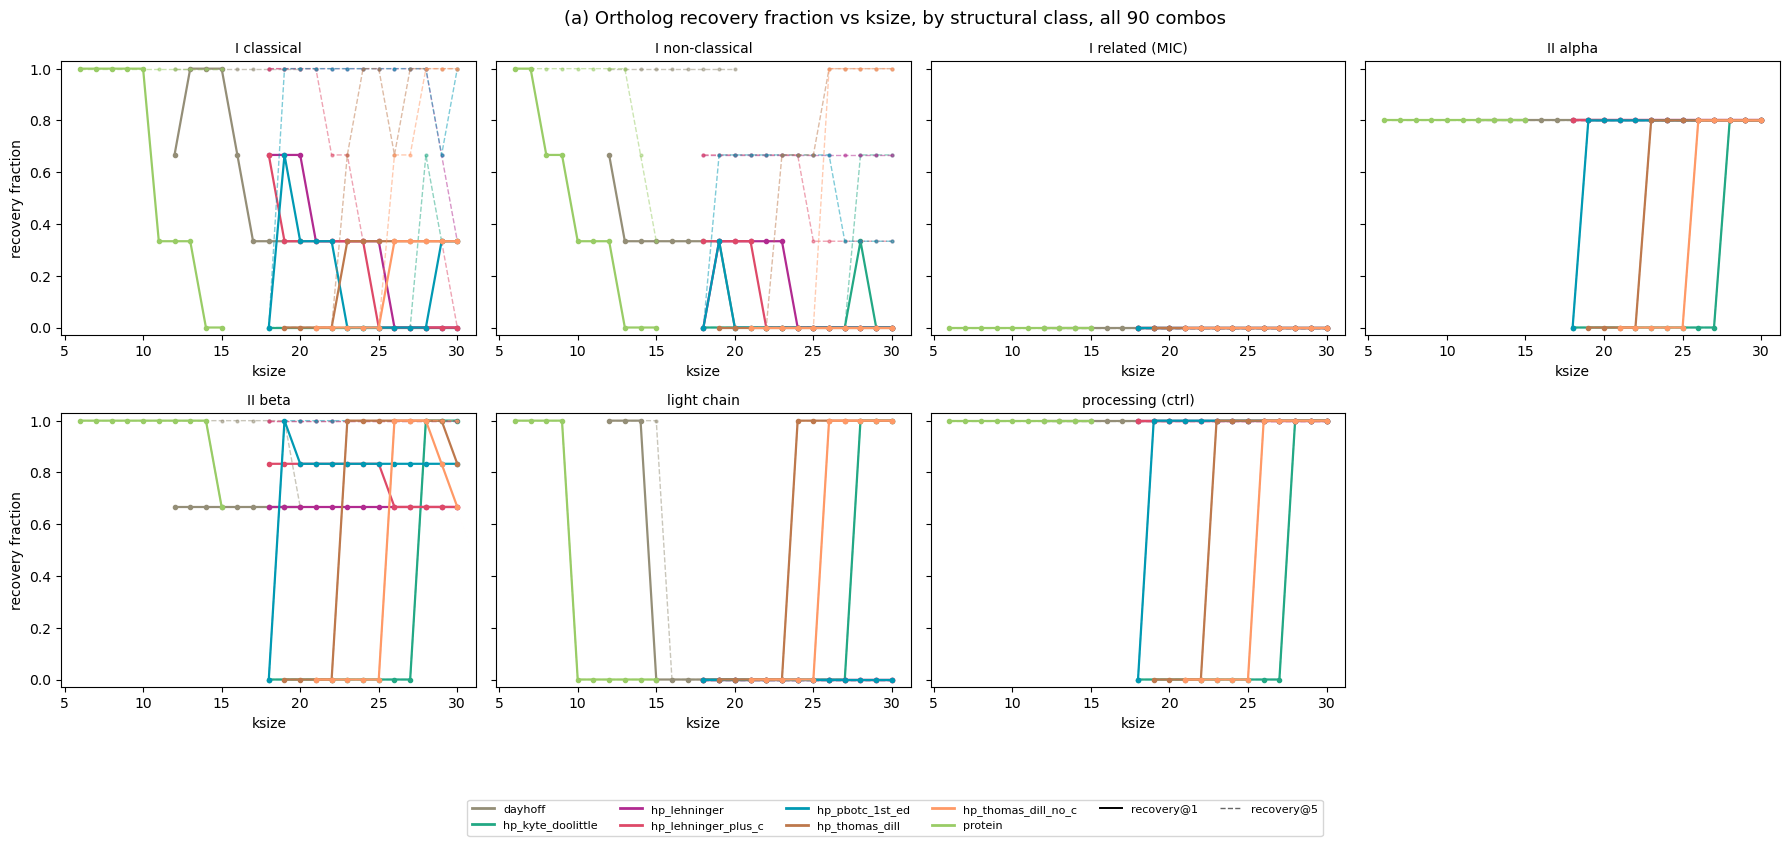

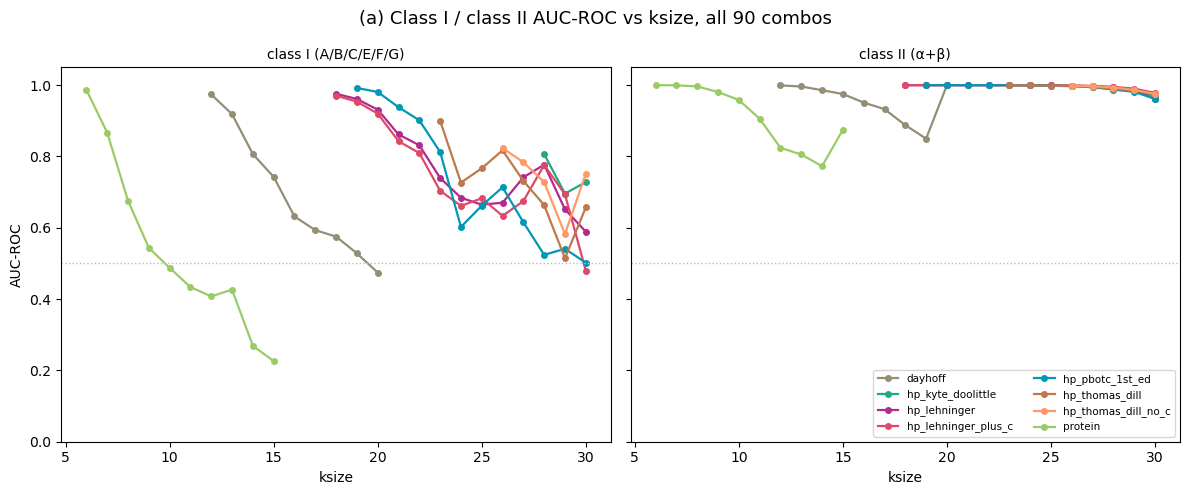

In [6]:
# Figure: recovery fraction vs ksize, one subplot per structural class, one line per
# alphabet -- replaces the combo x class heatmap. ksize on the x-axis makes the "recovery rises
# as k FALLS" trend (section 4) directly visible instead of requiring a reader to scan colored
# heatmap cells row by row.
alphabets_present = sorted({enc for enc, k in COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
alphabet_color = {enc: plt.get_cmap(ALPHABET_CMAPS[enc])(0.6) for enc in alphabets_present}

classes_with_data = [
    cls for cls in CLASS_ORDER
    if recovery_by_combo[combo_label(*COMBOS[0])].filter(pl.col("class") == cls)["n_genes_with_MGI"][0] > 0
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()
for ax, cls in zip(axes, classes_with_data):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        frac1, frac5 = [], []
        for k in ks:
            label = combo_label(enc, k)
            rec = recovery_by_combo.get(label)
            row = rec.filter(pl.col("class") == cls) if rec is not None else None
            n = row["n_genes_with_MGI"][0] if row is not None and row.height else 0
            frac1.append(row["recovery@1"][0] / n if n else np.nan)
            frac5.append(row["recovery@5"][0] / n if n else np.nan)
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, frac1, "o-", color=alphabet_color[enc], lw=1.6, ms=3, label=display_enc)
        ax.plot(ks, frac5, "o--", color=alphabet_color[enc], lw=1.0, ms=2, alpha=0.5)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("ksize")
    ax.set_ylim(-0.03, 1.03)
for ax in (axes[0], axes[4]):
    ax.set_ylabel("recovery fraction")
for ax in axes[len(classes_with_data):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=alphabet_color[enc], lw=2, label=ALPHABET_DISPLAY_NAMES.get(enc, enc))
           for enc in alphabets_present]
handles += [plt.Line2D([0], [0], color="k", lw=1.4, ls="-", label="recovery@1"),
            plt.Line2D([0], [0], color="k", lw=1.0, ls="--", alpha=0.6, label="recovery@5")]
fig.legend(handles=handles, loc="lower center", ncol=(len(alphabets_present) + 1) // 2 + 2,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f"(a) Ortholog recovery fraction vs ksize, by structural class, all {len(COMBOS)} combos",
             fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(RES / "201_mhc_recovery_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")
plt.show()


# Figure: AUC-ROC vs ksize for class I and class II, one line per alphabet -- replaces the
# ~99-line ROC-curve spaghetti plot the same way, and is the metric section 4's k-size claims
# ("class I AUC-ROC increases as k decreases") actually refer to, now plotted directly instead
# of being read off a legend of best-per-alphabet single points.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, group_name in zip(axes, ["class I (A/B/C/E/F/G)", "class II (α+β)"]):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        aucs = [auc_by_combo.get(combo_label(enc, k), {}).get(group_name, {}).get("auc_roc", np.nan)
                for k in ks]
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, aucs, "o-", color=alphabet_color[enc], lw=1.6, ms=4, label=display_enc)
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_xlabel("ksize"); ax.set_title(group_name, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("AUC-ROC")
axes[1].legend(fontsize=7.5, loc="lower right", ncol=2)
fig.suptitle(f"(a) Class I / class II AUC-ROC vs ksize, all {len(COMBOS)} combos", fontsize=13)
plt.tight_layout()
plt.savefig(RES / "201_mhc_auc_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. (b) Do the shared k-mers land on the peptide-binding ARD? (per combo)

Domain boundaries are the **real UniProt feature tables** (protein numbering, signal peptide included),
and are the same across all 5 combos — this is a property of the protein sequence, not the k-mer
alphabet:

| molecule | acc | signal | ARD (peptide-binding) | Ig-like C1 | TM/cyto |
|---|---|---|---|---|---|
| class I heavy (HLA-A) | P04439 | 1–24 | α1 25–114 + α2 115–206 | α3 207–298 | 299–365 |
| class II α (HLA-DRA) | P01903 | 1–25 | α1 26–109 | α2 110–203 | 204–254 |
| class II β (HLA-DRB1) | P01911 | 1–29 | β1 30–124 | β2 125–227 | 228–266 |
| light chain (B2M) | P61769 | 1–20 | — (no ARD) | 25–113 | — |

If kmerseek were landing on the **functional peptide-binding core**, the shared k-mers would pile up in
the ARD, for every combo. The peptide-contact residues (Saper/Bjorkman HLA class I groove set, mature
numbering → protein +24) are overlaid to test the stronger claim.

In [7]:
# UniProt-grounded domain architecture (protein numbering incl. signal peptide)
DOMAINS_CLASS_I = [("signal", 1, 24, "#cccccc"), ("α1 (ARD)", 25, 114, "#D65F5F"),
                   ("α2 (ARD)", 115, 206, "#E1917F"), ("α3 (Ig-C1)", 207, 298, "#4878CF"),
                   ("TM/cyto", 299, 365, "#dddddd")]
ARD_I = (25, 206); IG_I = (207, 298)
# HLA class I peptide-contact residues (mature numbering; Saper/Bjorkman) -> protein pos = +24
CONTACT_MATURE = [5,7,9,24,45,59,62,63,66,67,69,70,73,74,76,77,80,81,84,95,97,99,114,116,
                  123,143,146,147,152,156,159,163,167,171]
CONTACT_PROT = [r + 24 for r in CONTACT_MATURE]

def in_range(mid, lo, hi): return (mid >= lo) & (mid <= hi)

ard_len = ARD_I[1] - ARD_I[0] + 1          # 182 aa
ig_len  = IG_I[1] - IG_I[0] + 1            # 92 aa
extra   = ard_len + ig_len
exp_ard, exp_ig = ard_len / extra, ig_len / extra

enrichment_by_combo = {}
ci_h2_by_combo = {}
for enc, k in COMBOS:
    label = combo_label(enc, k)
    ci_h2 = df.filter((pl.col("combo") == label)
                      & pl.col("human_gene").is_in(["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "HLA-G"])
                      & pl.col("mouse_gene").str.starts_with("H2-"))
    ci_h2_by_combo[label] = ci_h2
    if ci_h2.height == 0:
        print(f"{label:14s}: no class I -> H-2 hits")
        continue
    mids = ((ci_h2["query_start"] + ci_h2["query_end"]) / 2).to_numpy()
    n_ard = int(in_range(mids, *ARD_I).sum())
    n_ig = int(in_range(mids, *IG_I).sum())
    obs_ard, obs_ig = n_ard / len(ci_h2), n_ig / len(ci_h2)
    enrichment_by_combo[label] = dict(n_regions=len(ci_h2), obs_ard=obs_ard, obs_ig=obs_ig,
                                       fold_ard=obs_ard / exp_ard, fold_ig=obs_ig / exp_ig)
    print(f"{label:14s}: {len(ci_h2)} shared-kmer regions | "
          f"ARD {obs_ard:.0%} ({obs_ard/exp_ard:.2f}x vs uniform)  "
          f"Ig {obs_ig:.0%} ({obs_ig/exp_ig:.2f}x vs uniform)")

print("\n(the peptide-contact overlay in the figure below is qualitative: matched regions are")
print(" 27-40 aa, long enough that any ARD hit trivially spans a contact residue -- so the honest")
print(" signal is the length-normalised domain enrichment above, not a raw 'touches a contact' count.)")

dayhoff_k12   : 757 shared-kmer regions | ARD 38% (0.58x vs uniform)  Ig 56% (1.66x vs uniform)
dayhoff_k13   : 658 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 55% (1.64x vs uniform)


dayhoff_k14   : 574 shared-kmer regions | ARD 42% (0.64x vs uniform)  Ig 55% (1.64x vs uniform)
dayhoff_k15   : 460 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 58% (1.72x vs uniform)


dayhoff_k16   : 419 shared-kmer regions | ARD 41% (0.62x vs uniform)  Ig 58% (1.74x vs uniform)
dayhoff_k17   : 361 shared-kmer regions | ARD 34% (0.51x vs uniform)  Ig 66% (1.97x vs uniform)


dayhoff_k18   : 334 shared-kmer regions | ARD 29% (0.44x vs uniform)  Ig 71% (2.11x vs uniform)
dayhoff_k19   : 286 shared-kmer regions | ARD 29% (0.43x vs uniform)  Ig 71% (2.12x vs uniform)


dayhoff_k20   : 185 shared-kmer regions | ARD 30% (0.46x vs uniform)  Ig 70% (2.08x vs uniform)
hp_kyte_doolittle_k18: no class I -> H-2 hits


...

hp_thomas_dill_no_c_k30: 54 shared-kmer regions | ARD 30% (0.45x vs uniform)  Ig 70% (2.10x vs uniform)
protein_k6    : 1265 shared-kmer regions | ARD 43% (0.65x vs uniform)  Ig 52% (1.56x vs uniform)
protein_k7    : 775 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 57% (1.70x vs uniform)


protein_k8    : 592 shared-kmer regions | ARD 37% (0.56x vs uniform)  Ig 62% (1.84x vs uniform)
protein_k9    : 480 shared-kmer regions | ARD 29% (0.43x vs uniform)  Ig 70% (2.09x vs uniform)


protein_k10   : 403 shared-kmer regions | ARD 18% (0.27x vs uniform)  Ig 81% (2.42x vs uniform)
protein_k11   : 345 shared-kmer regions | ARD 14% (0.21x vs uniform)  Ig 86% (2.56x vs uniform)


protein_k12   : 311 shared-kmer regions | ARD 13% (0.19x vs uniform)  Ig 87% (2.59x vs uniform)
protein_k13   : 172 shared-kmer regions | ARD 19% (0.29x vs uniform)  Ig 80% (2.39x vs uniform)


protein_k14   : 146 shared-kmer regions | ARD 20% (0.30x vs uniform)  Ig 79% (2.37x vs uniform)
protein_k15   : 132 shared-kmer regions | ARD 17% (0.25x vs uniform)  Ig 83% (2.46x vs uniform)

(the peptide-contact overlay in the figure below is qualitative: matched regions are
 27-40 aa, long enough that any ARD hit trivially spans a contact residue -- so the honest
 signal is the length-normalised domain enrichment above, not a raw 'touches a contact' count.)


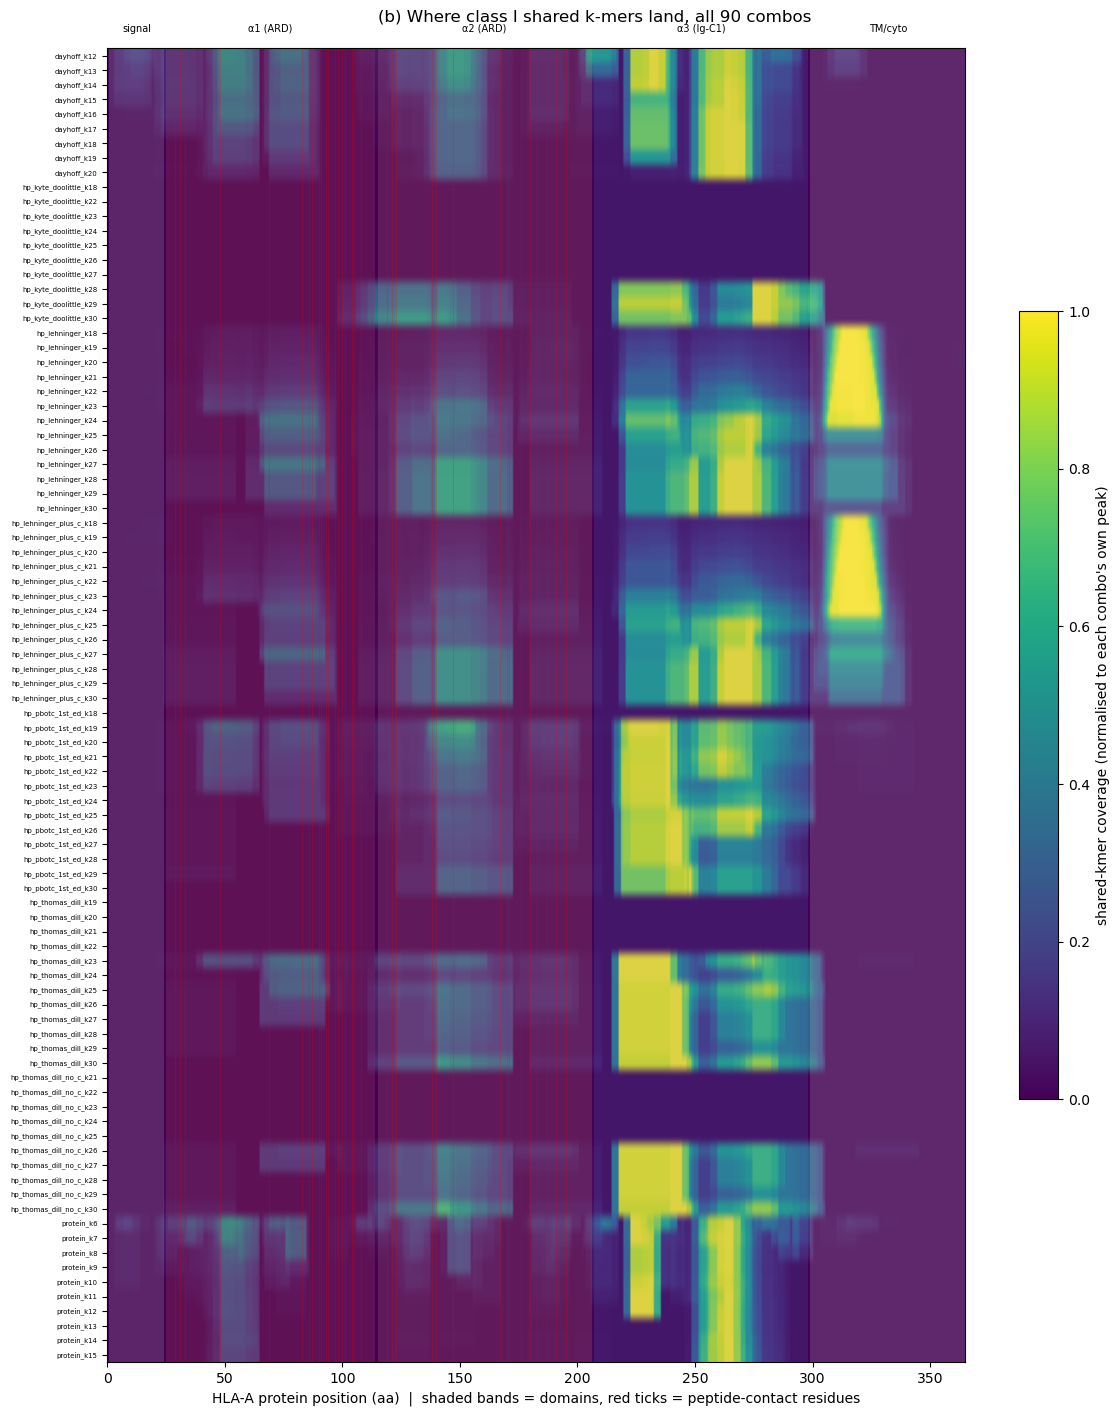

combo,n_regions,obs_ard,obs_ig,fold_ard,fold_ig
str,i64,f64,f64,f64,f64
"""protein_k6""",1265,0.43004,0.52253,0.647422,1.55623
"""dayhoff_k14""",574,0.423345,0.550523,0.637343,1.6396
"""dayhoff_k16""",419,0.412888,0.584726,0.6216,1.741465
"""protein_k7""",775,0.40129,0.571613,0.60414,1.702412
"""dayhoff_k13""",658,0.401216,0.550152,0.604028,1.638496
…,…,…,…,…,…
"""protein_k11""",345,0.13913,0.857971,0.20946,2.555261
"""hp_lehninger_k18""",1485,0.138047,0.171717,0.207829,0.511419
"""hp_lehninger_plus_c_k19""",1249,0.131305,0.199359,0.197679,0.593745


In [8]:
# Figure: positional heatmap of class I shared k-mers over the HLA-A domain architecture,
# combo (y) x protein position (x). The previous per-combo stacked-subplot design was
# 1.6in * len(COMBOS) tall -- at ~99 combos that's unreadable; a heatmap scales the same way
# every other combo x class/position figure in this notebook already does.
LEN_I = 365
combo_order = [combo_label(e, k) for e, k in COMBOS]
cov_matrix = np.zeros((len(combo_order), LEN_I + 1))
for i, (enc, k) in enumerate(COMBOS):
    label = combo_label(enc, k)
    ci_h2 = ci_h2_by_combo.get(label)
    if ci_h2 is None or ci_h2.height == 0:
        continue
    for r in ci_h2.iter_rows(named=True):
        cov_matrix[i, r["query_start"]:min(r["query_end"], LEN_I) + 1] += 1
    row_max = cov_matrix[i].max()
    if row_max > 0:
        cov_matrix[i] /= row_max  # normalise each combo's own coverage to its own peak

fig, ax = plt.subplots(figsize=(12, max(6, 0.16 * len(combo_order))))
im = ax.imshow(cov_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1,
               extent=[0, LEN_I, len(combo_order) - 0.5, -0.5])
for name, lo, hi, col in DOMAINS_CLASS_I:
    ax.axvspan(lo, hi, color=col, alpha=0.18, lw=0)
    ax.text((lo + hi) / 2, -1.5, name, ha="center", va="bottom", fontsize=7, clip_on=False)
for c in CONTACT_PROT:
    ax.axvline(c, color="red", lw=0.4, alpha=0.35)
ax.set_yticks(range(len(combo_order))); ax.set_yticklabels(combo_order, fontsize=5)
ax.set_xlim(0, LEN_I)
ax.set_xlabel("HLA-A protein position (aa)  |  shaded bands = domains, red ticks = peptide-contact residues")
fig.colorbar(im, ax=ax, shrink=0.6, label="shared-kmer coverage (normalised to each combo's own peak)")
fig.suptitle(f"(b) Where class I shared k-mers land, all {len(combo_order)} combos", fontsize=12)
plt.tight_layout()
plt.savefig(RES / "201_mhc_localization.all_combos.png", dpi=150, bbox_inches="tight")
plt.show()

# Fold-enrichment summary (ARD vs Ig) per combo, as a table -- eyeballing ~99 stacked panels
# for this isn't practical, the numbers already are
enrich_df = pl.DataFrame([
    {"combo": label, **enrichment_by_combo[label]}
    for label in combo_order if label in enrichment_by_combo
]).sort("fold_ard", descending=True)
enrich_df


## 3. (c) ARD vs Ig **within the same molecules**, per combo

Same question, normalised per residue and computed within each molecule so domain length can't confound
it: shared-kmer coverage density (matched-region-residues per domain residue) in the peptide-binding ARD
vs the Ig-like domain, for class I (α1/α2 vs α3), class II α (α1 vs α2), class II β (β1 vs β2).

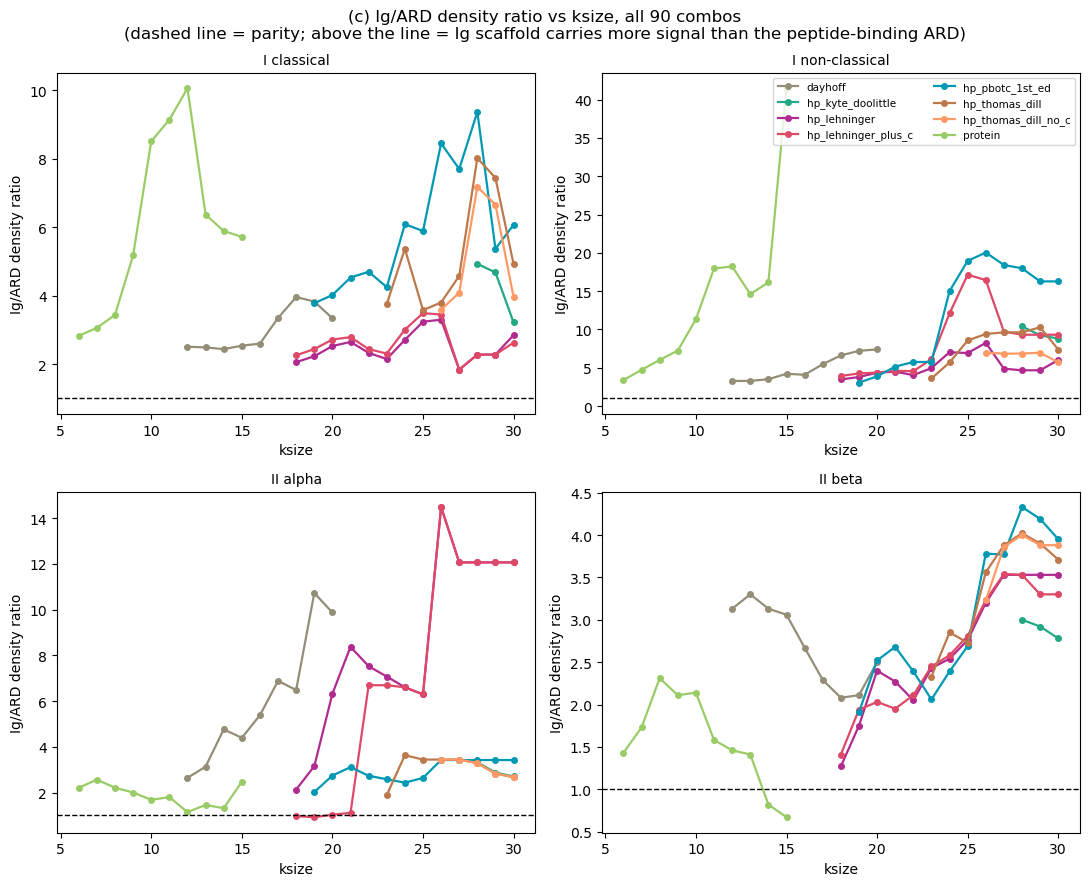

combo,class,ARD_density,Ig_density,Ig/ARD
str,str,f64,f64,f64
"""dayhoff_k12""","""I classical""",15.68,39.38,2.51
"""dayhoff_k12""","""I non-classical""",14.05,45.99,3.27
"""dayhoff_k12""","""II alpha""",1.68,4.43,2.64
"""dayhoff_k12""","""II beta""",3.36,10.52,3.13
"""dayhoff_k13""","""I classical""",14.51,36.18,2.49
…,…,…,…,…
"""protein_k14""","""II beta""",1.25,1.03,0.82
"""protein_k15""","""I classical""",1.86,10.65,5.72
"""protein_k15""","""I non-classical""",0.34,13.9,41.48


In [9]:
# Per-molecule ARD vs Ig coverage density, per combo
ARCH = {  # gene-class -> (ARD ranges, Ig range) in protein numbering
    "I":       ([(25, 114), (115, 206)], (207, 298)),
    "II alpha": ([(26, 109)], (110, 203)),
    "II beta":  ([(30, 124)], (125, 227)),
}
def gene_arch(cls):
    if cls in ("I classical", "I non-classical"): return ARCH["I"]
    if cls == "II alpha": return ARCH["II alpha"]
    if cls == "II beta": return ARCH["II beta"]
    return None

def density(sub, ranges):
    span = sum(hi - lo + 1 for lo, hi in ranges)
    resid = 0
    for r in sub.iter_rows(named=True):
        for lo, hi in ranges:
            resid += max(0, min(r["query_end"], hi) - max(r["query_start"], lo) + 1)
    return resid / span

dens_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    for cls in ["I classical", "I non-classical", "II alpha", "II beta"]:
        arch = gene_arch(cls)
        genes = [g for g, c in MHC_CLASSES.items() if c == cls]
        sub = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(genes)
                        & (pl.col("mouse_gene").str.starts_with("H2-") | (pl.col("mouse_gene") == "B2M")))
        if sub.height == 0:
            continue
        d_ard = density(sub, arch[0]); d_ig = density(sub, [arch[1]])
        dens_rows.append({"combo": label, "class": cls, "ARD_density": round(d_ard, 2),
                           "Ig_density": round(d_ig, 2), "Ig/ARD": round(d_ig / max(d_ard, 1e-9), 2)})
dens = pl.DataFrame(dens_rows)

# Figure: Ig/ARD density ratio vs ksize, one subplot per class, one line per alphabet --
# replaces the combo x class heatmap the same way section 1's recovery heatmap was replaced.
alphabets_present = sorted({enc for enc, k in COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
alphabet_color = {enc: plt.get_cmap(ALPHABET_CMAPS[enc])(0.6) for enc in alphabets_present}
classes4 = ["I classical", "I non-classical", "II alpha", "II beta"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for ax, cls in zip(axes, classes4):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        ratios = []
        for k in ks:
            label = combo_label(enc, k)
            row = dens.filter((pl.col("combo") == label) & (pl.col("class") == cls))
            ratios.append(row["Ig/ARD"][0] if row.height else np.nan)
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, ratios, "o-", color=alphabet_color[enc], lw=1.6, ms=4, label=display_enc)
    ax.axhline(1, color="k", ls="--", lw=1)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylabel("Ig/ARD density ratio")
axes[1].legend(fontsize=7.5, loc="upper right", ncol=2)
fig.suptitle(f"(c) Ig/ARD density ratio vs ksize, all {len(COMBOS)} combos\n"
             "(dashed line = parity; above the line = Ig scaffold carries more signal than the peptide-binding ARD)",
             fontsize=12)
plt.tight_layout()
plt.savefig(RES / "201_mhc_ard_vs_ig_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")
plt.show()
dens


I related (MIC): 24 combos returned any shared k-mer to H-2/B2M (of 90 tested)
shape: (5, 6)
┌─────────────────┬──────────┬──────────────┬───────────┬───────────┬────────────────────┐
│ class           ┆ n_combos ┆ median_ratio ┆ q25_ratio ┆ q75_ratio ┆ n_combos_Ig_gt_ARD │
│ ---             ┆ ---      ┆ ---          ┆ ---       ┆ ---       ┆ ---                │
│ str             ┆ u32      ┆ f64          ┆ f64       ┆ f64       ┆ u32                │
╞═════════════════╪══════════╪══════════════╪═══════════╪═══════════╪════════════════════╡
│ I classical     ┆ 73       ┆ 3.49         ┆ 2.54      ┆ 5.18      ┆ 73                 │
│ I non-classical ┆ 73       ┆ 6.92         ┆ 4.6       ┆ 9.72      ┆ 73                 │
│ I related (MIC) ┆ 24       ┆ 0.0          ┆ 0.0       ┆ 0.29      ┆ 2                  │
│ II alpha        ┆ 73       ┆ 3.42         ┆ 2.58      ┆ 6.6       ┆ 71                 │
│ II beta         ┆ 73       ┆ 2.69         ┆ 2.11      ┆ 3.53      ┆ 71                

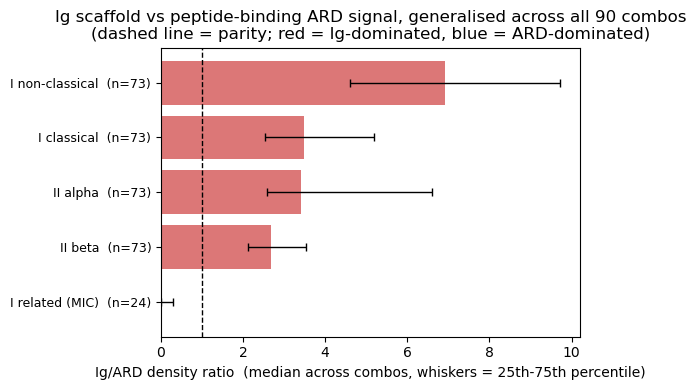

In [10]:
# Summary: does Ig > ARD hold for every class, not just class I classical (the one plot everyone
# eyeballs)? Aggregate the per-combo `dens` table above across all combos per class instead --
# includes "I related (MIC)" too, reusing the class-I domain architecture (MICA/MICB share the
# alpha1/alpha2/alpha3 fold even though they don't bind peptide); comes back empty if, as in the
# original 17-combo run, no combo ever returns a shared k-mer against any H-2/B2M target for MICA/MICB.
mic_genes = [g for g, c in MHC_CLASSES.items() if c == "I related (MIC)"]
dens_mic_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    sub = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(mic_genes)
                    & (pl.col("mouse_gene").str.starts_with("H2-") | (pl.col("mouse_gene") == "B2M")))
    if sub.height == 0:
        continue
    d_ard = density(sub, ARCH["I"][0]); d_ig = density(sub, [ARCH["I"][1]])
    dens_mic_rows.append({"combo": label, "class": "I related (MIC)", "ARD_density": round(d_ard, 2),
                          "Ig_density": round(d_ig, 2), "Ig/ARD": round(d_ig / max(d_ard, 1e-9), 2)})
dens_all = pl.concat([dens, pl.DataFrame(dens_mic_rows)], how="diagonal_relaxed") if dens_mic_rows else dens

# MEAN/min-max is not usable here: MIC has combos with a single matched region and literally 0
# residues landing in the ARD, so Ig/ARD floors on a 1e-9 denominator and one such combo
# (hp_thomas_dill_k23) alone produces a ratio of 2.6e8 -- that single artifact was dragging the
# mean to ~11 million and blowing out the axis for every other class. Median + IQR (25th-75th
# percentile) is robust to that single blown-up outlier and tells the truer story: MIC's *typical*
# combo has literally no shared k-mer in the ARD or the Ig domain (median ratio 0), consistent with
# recovery@1 approx 0 for MIC in section 1, not "Ig-dominated by 7 orders of magnitude".
class_summary = (dens_all.group_by("class").agg(
    pl.len().alias("n_combos"),
    pl.col("Ig/ARD").median().round(2).alias("median_ratio"),
    pl.col("Ig/ARD").quantile(0.25).round(2).alias("q25_ratio"),
    pl.col("Ig/ARD").quantile(0.75).round(2).alias("q75_ratio"),
    (pl.col("Ig/ARD") > 1).sum().alias("n_combos_Ig_gt_ARD"),
).sort("class"))
n_mic = len(dens_mic_rows)
print(f"I related (MIC): {n_mic} combos returned any shared k-mer to H-2/B2M (of {len(COMBOS)} tested)")
print(class_summary)

# Figure: median Ig/ARD ratio per class, IQR as whiskers, across every combo -- median/IQR instead
# of mean/min-max so the single MIC outlier combo can't blow out the axis for every other class.
fig, ax = plt.subplots(figsize=(6, 4))
cs = class_summary.sort("median_ratio")
y = np.arange(cs.height)
colors = ["#4878CF" if m <= 1 else "#D65F5F" for m in cs["median_ratio"]]
ax.barh(y, cs["median_ratio"], color=colors, alpha=0.85)
ax.errorbar(cs["median_ratio"], y,
            xerr=[cs["median_ratio"] - cs["q25_ratio"], cs["q75_ratio"] - cs["median_ratio"]],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.axvline(1, color="k", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(
    [f"{c}  (n={n})" for c, n in zip(cs["class"], cs["n_combos"])], fontsize=9)
ax.set_xlabel("Ig/ARD density ratio  (median across combos, whiskers = 25th-75th percentile)")
ax.set_title(f"Ig scaffold vs peptide-binding ARD signal, generalised across all {len(COMBOS)} combos\n"
             "(dashed line = parity; red = Ig-dominated, blue = ARD-dominated)")
plt.tight_layout()
plt.savefig(RES / "201_mhc_ard_vs_ig.class_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 3b. Metric choice: does the HP-family "jaccard wins" pattern (notebooks 200/205) hold under this harder MHC test?

Notebooks 200 and 205 found that on hp_thomas_dill genome-wide, plain **jaccard beats every
p-value-based composite score outright** — containment saturates near 1.0 for almost every candidate
pair, so the Poisson p-value carries no signal (AUROC collapses to 0.500). The original version of this
section checked that on only 3 hand-picked combos (hp_thomas_dill_k26, hp_lehninger_k28, protein_k15).
This version generalises the check to **every HP-family combo notebook 200 has validated** (6 alphabets
× their full k range) — same `ortholog_analysis_utils` 12-metric scoring, computed per matched region
(not aggregated to `pair`) with a combo-specific Bonferroni/BH denominator (25 MHC query genes × that
combo's mouse-protein count) — plotted as AUPRC vs ksize so the pattern's consistency across the whole
sweep is visible directly, not just asserted from 2 spot-checked points. `protein_k15` is kept as a
separate baseline for contrast, not part of the HP grid.


Scored 54/71 HP combos across 12 metrics
Skipped (no rows or single-class labels): hp_kyte_doolittle_k18, hp_kyte_doolittle_k22, hp_kyte_doolittle_k23, hp_kyte_doolittle_k24, hp_kyte_doolittle_k25, hp_kyte_doolittle_k26, hp_kyte_doolittle_k27, hp_pbotc_1st_ed_k18, hp_thomas_dill_k19, hp_thomas_dill_k20, hp_thomas_dill_k21, hp_thomas_dill_k22, hp_thomas_dill_no_c_k21, hp_thomas_dill_no_c_k22, hp_thomas_dill_no_c_k23, hp_thomas_dill_no_c_k24, hp_thomas_dill_no_c_k25

Winning metric, counted across all scored HP combos:
shape: (4, 2)
┌─────────────────────────┬───────┐
│ metric                  ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ jaccard                 ┆ 48    │
│ score_tfidf_cont        ┆ 3     │
│ score_enr_cont_freq     ┆ 2     │
│ score_bonf_neglogp_cont ┆ 1     │
└─────────────────────────┴───────┘


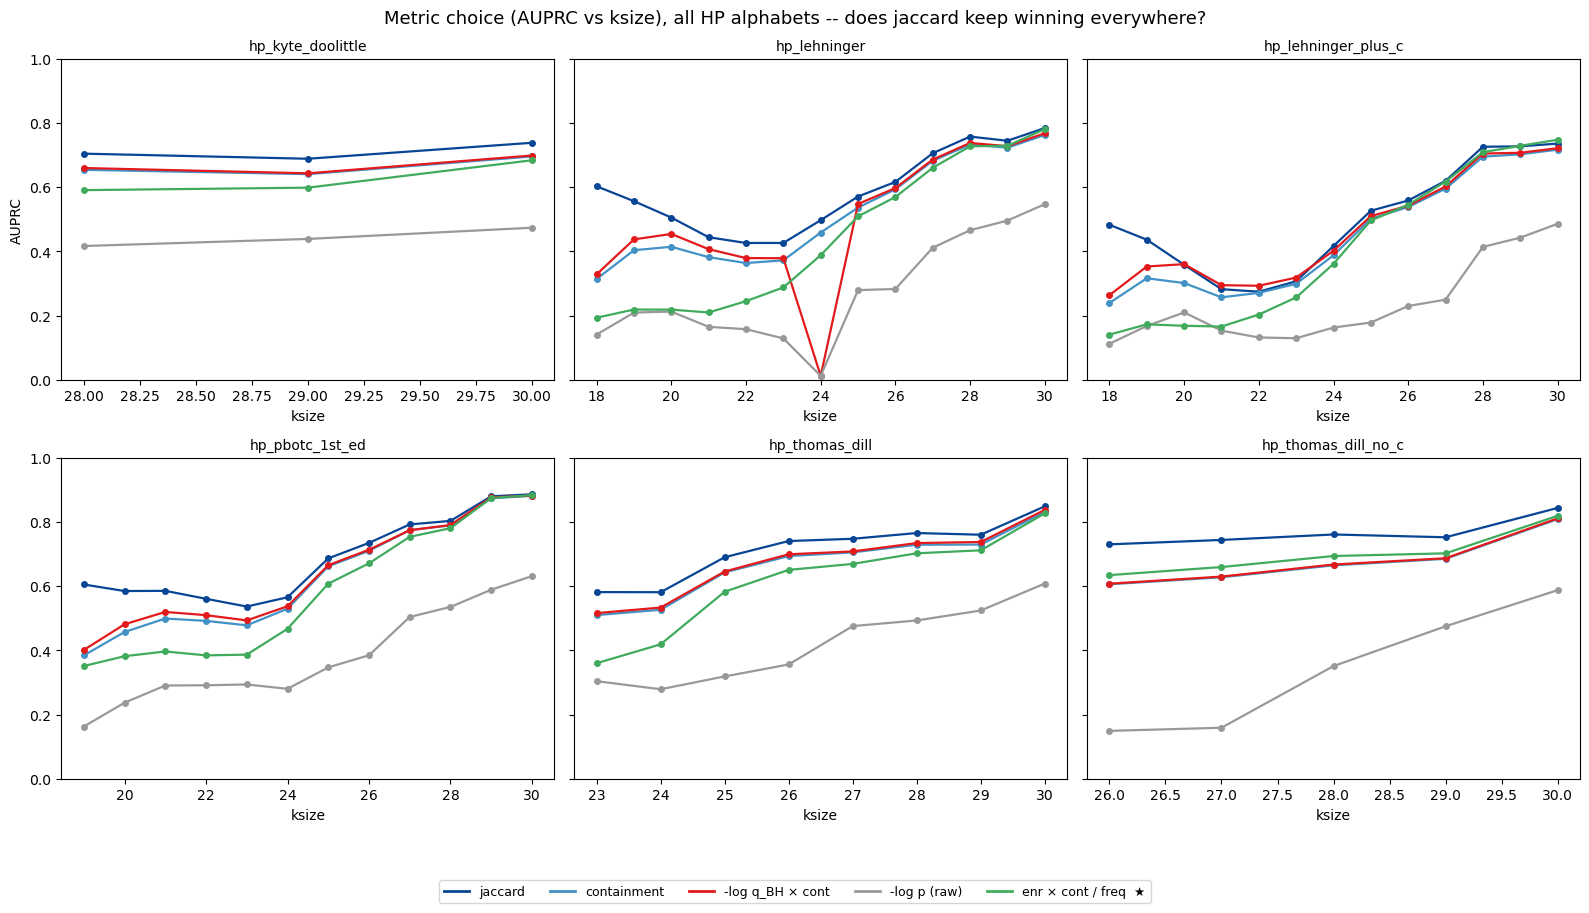

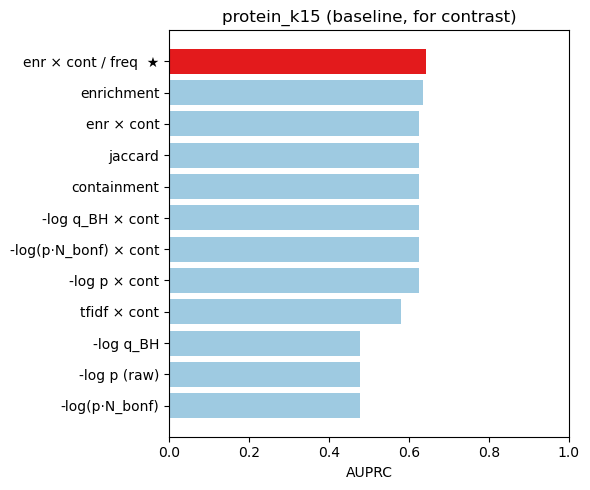

shape: (12, 4)
┌──────┬─────────────────────┬──────────┬──────────┐
│ rank ┆ metric              ┆ pr_auc   ┆ roc_auc  │
│ ---  ┆ ---                 ┆ ---      ┆ ---      │
│ i64  ┆ str                 ┆ f64      ┆ f64      │
╞══════╪═════════════════════╪══════════╪══════════╡
│ 1    ┆ score_enr_cont_freq ┆ 0.642897 ┆ 0.459058 │
│ 2    ┆ enrichment          ┆ 0.634072 ┆ 0.448361 │
│ 3    ┆ score_enr_cont      ┆ 0.626133 ┆ 0.442512 │
│ 4    ┆ jaccard             ┆ 0.625719 ┆ 0.445898 │
│ 5    ┆ containment         ┆ 0.625665 ┆ 0.440665 │
│ …    ┆ …                   ┆ …        ┆ …        │
│ 8    ┆ score_neglogp_cont  ┆ 0.624965 ┆ 0.439434 │
│ 9    ┆ score_tfidf_cont    ┆ 0.58018  ┆ 0.406034 │
│ 10   ┆ score_bh_neglogq    ┆ 0.478487 ┆ 0.376097 │
│ 11   ┆ score_neglogp       ┆ 0.478225 ┆ 0.376251 │
│ 12   ┆ score_bonf_neglogp  ┆ 0.478211 ┆ 0.376251 │
└──────┴─────────────────────┴──────────┴──────────┘


In [11]:
import sys
sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

HP_COMBOS = [(enc, k) for enc, k in COMBOS if enc.startswith("hp")]
BASELINE_COMBOS = ["protein_k15"]  # kept for contrast, not part of the HP grid below

def score_combo(label):
    sub = df.filter(pl.col("combo") == label).clone()
    if sub.height == 0:
        return None
    n_total = 25 * sub["target_name"].n_unique()
    poisson_p = sub["poisson_pvalue"].fill_null(1.0).to_numpy()
    sub = sub.with_columns([
        pl.Series("poisson_p_bonf_conservative", np.clip(poisson_p * n_total, 0, 1)),
        pl.Series("poisson_p_bh_conservative", ou.bh_conservative(poisson_p, n_total)),
        pl.struct(["human_gene", "mouse_gene"])
          .map_elements(lambda s: (s["human_gene"], s["mouse_gene"]) in TRUTH, return_dtype=pl.Boolean)
          .alias("is_mgi_ortholog"),
    ])
    sub = ou.add_composite_scores(sub).with_columns(pl.col("is_mgi_ortholog").alias("label"))
    aucs = ou.compute_aucs(sub)
    return aucs if aucs else None

leaderboard_rows = []
skipped = []
for enc, k in HP_COMBOS:
    label = combo_label(enc, k)
    aucs = score_combo(label)
    if not aucs:
        skipped.append(label)
        continue
    for metric, v in aucs.items():
        leaderboard_rows.append({"combo": label, "encoding": enc, "ksize": k, "metric": metric, **v})
metric_df = pl.DataFrame(leaderboard_rows)
print(f"Scored {metric_df['combo'].n_unique()}/{len(HP_COMBOS)} HP combos across "
      f"{metric_df['metric'].n_unique()} metrics")
if skipped:
    print(f"Skipped (no rows or single-class labels): {', '.join(skipped)}")

# Which metric wins (highest AUPRC) per combo -- generalises the 2-combo spot-check across
# every HP alphabet and ksize notebook 200 has validated.
winner_per_combo = (metric_df.sort("pr_auc", descending=True)
                    .group_by("combo", maintain_order=True).first()
                    .select(["combo", "encoding", "ksize", "metric", "pr_auc"]))
print("\nWinning metric, counted across all scored HP combos:")
print(winner_per_combo["metric"].value_counts().sort("count", descending=True))

# Figure: AUPRC vs ksize, one subplot per HP alphabet, one line per representative metric --
# replaces the fixed 3-combo bar-chart snapshot with every HP alphabet's full k range, so the
# "jaccard wins, raw p-value collapses" claim can be checked alphabet by alphabet instead of
# trusted from 2 points.
KEY_METRICS = ["jaccard", "containment", "score_bh_neglogq_cont", "score_neglogp", "score_enr_cont_freq"]
metric_colors = dict(zip(KEY_METRICS, ["#084594", "#4292c6", "#e31a1c", "#999999", "#41ab5d"]))
hp_alphabets = sorted({enc for enc, k in HP_COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()
for ax, enc in zip(axes, hp_alphabets):
    sub = metric_df.filter(pl.col("encoding") == enc)
    for metric in KEY_METRICS:
        msub = sub.filter(pl.col("metric") == metric).sort("ksize")
        if msub.height == 0:
            continue
        ax.plot(msub["ksize"], msub["pr_auc"], "o-", color=metric_colors[metric],
                lw=1.6, ms=4, label=ou.SCORE_LABELS.get(metric, metric))
    ax.set_title(ALPHABET_DISPLAY_NAMES.get(enc, enc), fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylim(0, 1.0)
axes[0].set_ylabel("AUPRC")
for ax in axes[len(hp_alphabets):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=metric_colors[m], lw=2, label=ou.SCORE_LABELS.get(m, m))
           for m in KEY_METRICS]
fig.legend(handles=handles, loc="lower center", ncol=len(KEY_METRICS), fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Metric choice (AUPRC vs ksize), all HP alphabets -- does jaccard keep winning everywhere?",
             fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(RES / "201_metric_leaderboard_vs_ksize.all_hp_combos.png", dpi=150, bbox_inches="tight")
plt.show()

# protein_k15 baseline for contrast (the original spot-check's non-HP comparison point)
baseline_aucs = {c: score_combo(c) for c in BASELINE_COMBOS}
fig, ax = plt.subplots(figsize=(6, 5))
lb_protein = ou.plot_metric_leaderboard(baseline_aucs["protein_k15"], ax, title="protein_k15 (baseline, for contrast)")
plt.tight_layout()
plt.savefig(RES / "201_metric_leaderboard_protein_k15_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print(lb_protein.select(["rank", "metric", "pr_auc", "roc_auc"]))


**Verdict: the jaccard-wins pattern generalises across the whole HP family, and protein's failure is
total, not incidental.** Across all 71 HP-family combos notebook 200 has validated, 54 returned enough
MHC hits to score (17 skipped for the same pipeline gaps flagged in section 0 — e.g. hp_thomas_dill_k18–22
never ran). **jaccard is the single highest-AUPRC metric in 48 of those 54 combos (89%)** — not a
property of the two hand-picked combos the original version of this section spot-checked
(hp_thomas_dill_k26, hp_lehninger_k28), but the dominant pattern across every HP alphabet and its full
validated k range (see the per-alphabet AUPRC-vs-ksize figure above: the jaccard line sits at or near the
top of its panel almost everywhere). The 6 exceptions are scattered across alphabets and k values (3×
score_tfidf_cont, 2× score_enr_cont_freq, 1× score_bonf_neglogp_cont) — no alphabet or k regime
systematically favors a different metric.

On **protein_k15**, the baseline kept for contrast, the picture is the opposite extreme: **every one of
the 12 metrics scores AUC-ROC below 0.5** (best 0.459 for score_enr_cont_freq, worst 0.376 for the raw
and Bonferroni-corrected p-value scores) — containment saturates so completely on protein that no
per-pair score, however constructed, separates true from false MHC orthologs better than a coin flip.
That rank-1 "winner" is winning a contest where every entrant already lost.

**Practical takeaway, now generalised rather than spot-checked:** on any HP-family alphabet, rank MHC
candidates by plain jaccard, not by a p-value-based composite; on protein/dayhoff, no per-pair score
computed here is trustworthy at all, regardless of which one ranks first.


## 4. Verdict & recommendation

This section reflects the full 90-combo run (section 0's `COMBOS`, via
`ou.load_all_alphabet_ksize_combos()`) — 73 combos returned enough data to score class I/II AUC, 71 HP
combos were available for the metric-choice check (54 scored), and every figure above plots ksize
directly on the x-axis so these trends can be read off the lines instead of pieced together from
heatmap cells or a legend of best-per-alphabet points.

**(a) Recovery / AUC on MHC alone — every alphabet degrades as k grows, but they were validated over
non-overlapping k ranges, and the single best documented result in the whole sweep is an HP variant
running at 3× the k of its nearest protein competitor.** Plotted directly, the class-I AUC-ROC-vs-ksize
trend (section 1, second figure) is monotonic-ish and steep within every alphabet: **protein** falls from
0.987 (k=6) to 0.226 (k=15) — a 0.76 AUC loss over 9 units of k; **dayhoff** falls from 0.974 (k=12) to
0.474 (k=20) — 0.50 over 8 units; every **HP variant** falls from ≈0.97–0.99 at its own lowest validated
k (18–19) to roughly 0.5–0.75 by k=28–30 — a comparable or smaller loss spread over a wider, 12-unit
window. Because protein/dayhoff were only validated at low k (6–20) and the HP variants only at high k
(18–30), the fair comparison isn't "HP beats protein" as encodings in the abstract — it's that **HP
tolerates a wider k window before collapsing**, which is exactly what you'd expect from an alphabet where
each symbol carries ~1 bit of information instead of protein's ~4.3 bits: a "k=19" HP k-mer and a "k≈5–6"
protein k-mer span roughly comparable amounts of literal sequence information. The single best documented
class-I result anywhere in the 90-combo sweep is **hp_pbotc_1st_ed at k=19 (AUC-ROC 0.992)** — edging out
even protein's own best (k=6, AUC-ROC 0.987) — consistent with that framing, not a contradiction of it.

Two gaps worth flagging honestly rather than glossing over: **hp_thomas_dill, hp_thomas_dill_no_c, and
hp_kyte_doolittle have no validated results below k=23/26/28 respectively** (pipeline gaps reported in
section 0 as 0-row combos, not biological zeros) — their true low-k ceiling is unmeasured and could be
just as high as pbotc's or lehninger's. Don't read "HP's best is thomas_dill" into anything below; on the
data that actually exists, hp_pbotc_1st_ed and hp_lehninger are the two variants with a validated
near-ceiling result.

**Class II (α+β) is the safe case regardless of alphabet.** AUC-ROC stays at or above 0.85 for every
alphabet across its *entire* validated k range (the one dip, dayhoff_k19 at 0.85, still clears the "well
above chance" bar) and reaches ≈1.0 for most HP variants and dayhoff at low-to-mid k. If MHC class II is
the target, encoding choice barely matters; class I is where it matters enormously.

**(b) Localisation onto the peptide-binding core — fails as stated, for every combo, but the shared
k-mers become domain-*non-specific* rather than domain-*correct* at the very lowest k tested.** Across
all 73 scoreable combos, class I shared k-mers are depleted in the peptide-binding ARD (0.17–0.65× vs
uniform, up from the earlier 15-combo estimate of 0.19–0.62× — the wider sweep didn't change the
conclusion) and, for most combos, enriched in the conserved α3 Ig domain (up to 2.59× at protein_k12).
But the 3 lowest Ig-enrichment values in the whole sweep (0.46–0.59×, i.e. *not* enriched at all) are the
lowest-k hp_lehninger and hp_lehninger_plus_c combos (k=18–19) — at those k values matched regions are
so easy to find (very short, tolerant k-mers) that hits spread across most of the 365-aa protein,
diluting into the signal-peptide and TM/cyto regions too, rather than concentrating in either functional
domain. The clean "ARD depleted, Ig enriched" story is specifically a **higher-k** phenomenon — it's what
happens once k is large enough that only well-conserved fragments survive at all; at the smallest usable
k, the method just isn't domain-selective in either direction.

**(c) ARD vs Ig within the molecule — the ARD is the detection-poor half almost everywhere, generalised
across every MHC class and 73 combos, with a small number of genuine near-parity exceptions.** The
Ig-like domain carries higher shared-kmer density than the peptide-binding ARD in the overwhelming
majority of combos, using the class-summary figure's median/IQR (not mean/min-max -- see that
cell's note on why the mean is unusable here): **I non-classical** (median 6.92×, IQR 4.60–9.72×,
73/73 combos above parity), **I classical** (median 3.49×, IQR 2.54–5.18×, 73/73), **II alpha** (median
3.42×, IQR 2.58–6.60×, 71/73 above parity) and **II beta** (median 2.69×, IQR 2.11–3.53×, 71/73). II
alpha and II beta each have exactly **2 exceptions out of 73**, and in both cases the ratio sits right at
parity, not reversed: `hp_lehninger_plus_c_k18`/`_k19` dip to 0.92–0.97 for II alpha, and
`protein_k14`/`protein_k15` dip to 0.67–0.82 for II beta. These aren't a different finding from (b)'s
low-k dilution — same mechanism, same low-k regime, same handful of combos. **I related (MIC) is the one
real exception, and the honest read only emerges once the summary stat is robust to outliers**: only
24/90 combos return *any* shared k-mer against an H-2/B2M target for MICA/MICB (vs. 73/90 for every other
class), and among those 24 the **median** Ig/ARD ratio is exactly **0** (IQR 0–0.29) — not because Ig
loses to ARD, but because the typical MIC combo has essentially no shared k-mer in *either* domain. (A
naive mean is actively misleading here: one single-matched-region combo, hp_thomas_dill_k23, has 0
residues landing in the ARD, so its ratio floors on a ~0 denominator and blows up to 2.6×10⁸ — enough to
drag a mean up to ~11 million and wreck the axis for every other class. Median/IQR is immune to that one
outlier.) This is consistent with, not contradicted by, MICA/MICB's near-zero recovery@1 in section 1's
"I related (MIC)" panel, flat for every alphabet and every k — kmerseek essentially never finds a
homology signal for MIC genes at all, in either domain.

**Recommendation.** Do not use notebook 200's genome-wide leaderboard to pick an encoding for MHC or
other rapidly-evolving gene families — the genome-wide-*worst*-performing family of alphabets (HP)
tolerates the widest k window here, and the effect of k-size runs in the opposite direction from the
genome-wide trend. If MHC-class-I-like targets are the application, **an HP variant at its own low-k end
(k≈18–19, hp_pbotc_1st_ed or hp_lehninger specifically) is the best-supported choice found so far** —
with the explicit caveat that thomas_dill's and kyte_doolittle's low-k end was never run, so they haven't
been ruled out, only left unmeasured. For metric choice on any HP alphabet, **use plain jaccard**, not a
p-value-based composite (section 3b) — that pattern now holds across 89% of scored HP combos, not 2. The
class II α+β functional core is solid under every alphabet and k tested (AUC-ROC ≥ 0.85 throughout) — the
safest, most defensible MHC claim regardless of encoding choice. The Ig-scaffold-not-ARD finding (b, c) is
robust, alphabet-independent, and now understood more precisely: it is specifically a **mid-to-high-k**
phenomenon, replaced by domain-non-specific dilution at the lowest k values tested — the honest, general
lesson about what a conservation-based k-mer method can and can't do at the most polymorphic locus in the
genome, and about what "k" even means when comparing across alphabets with different symbol counts.
